In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler



In [6]:
df = pd.read_csv(r"C:\Users\DIVYA\OneDrive\Desktop\creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
#CHECK FOR missing values
df.isnull().sum()

#Standardize 'Amount' features
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])

In [10]:
#select features for anomly detection
features = ['scaled_amount', 'Time'] + [f'V{i}' for i in range(1,29)]
X = df[features]


In [11]:
#apply isolation forest
model = IsolationForest(n_estimators =100, contamination = 0.001, random_state = 42)
df['anomaly'] = model.fit_predict(X)

#Anomly Score
df['anomaly_score'] = model.decision_function(X)

In [13]:
df[['scaled_amount', 'Time','anomaly','anomaly_score']].head(100)

,scaled_amount,Time,anomaly,anomaly_score
0,0.244964,0.0,1,0.301605
1,-0.342475,0.0,1,0.320436
2,1.160686,1.0,1,0.189178
3,0.140534,1.0,1,0.277670
4,-0.073403,2.0,1,0.297416
...,...,...,...,...
95,-0.133375,64.0,1,0.307190
96,-0.323044,64.0,1,0.249596
97,-0.273867,67.0,1,0.320818
98,-0.240164,67.0,1,0.286712


In [15]:
df[df['anomaly'] == -1].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,scaled_amount,anomaly,anomaly_score
1632,1264.0,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,34.303177,-7.520784,-1.925732,-2.636622,3.702177,-1.843056,2.427123,-1.652836,3.635042,4.087802,-1.654892,-0.888406,0.752276,-11.748689,-4.709977,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934,7712.43,0,30.481731,-1,-0.036620
2963,2507.0,-6.200114,5.025406,-2.742492,-0.940903,-6.656259,5.432294,-9.198175,-22.588547,-3.244295,-5.453339,-1.582292,2.771415,-0.794303,3.189651,-2.359859,2.825793,2.126128,-1.303542,-1.429571,4.592909,-11.235266,4.393846,1.943002,0.846005,-1.343379,-0.707634,-0.210219,0.066529,544.62,0,1.824208,-1,-0.001196
5425,5406.0,-8.733429,-5.681953,2.253879,3.930311,-0.916149,4.355297,5.400286,-4.994383,6.819787,6.764860,3.553336,-3.717391,0.665064,-4.496585,-0.533313,-1.143550,-0.777258,-0.988692,0.868138,-5.571503,-2.626882,1.525158,-1.428302,-0.030181,-0.029485,-0.264455,-7.976100,4.712560,553.60,0,1.860111,-1,-0.000869
6783,8544.0,-6.571336,-11.943892,-4.246322,6.825816,-2.896624,2.706661,5.373923,-0.872187,-0.626203,-0.955356,0.951596,-2.136055,2.352625,2.669868,-1.412917,1.233990,0.038883,0.915151,-2.348414,7.922141,2.220493,-2.395098,-3.731391,-1.015761,-0.740824,-0.297883,-0.793710,0.680622,4002.88,0,15.650630,-1,-0.008053
6812,8592.0,-23.066842,-25.640527,-3.080313,4.866932,6.901397,-4.074335,2.027345,-2.688652,3.402966,2.881873,3.236837,-2.889369,4.465413,-1.550096,1.928388,3.930881,-1.352591,-0.988008,2.693421,-13.276034,-5.378106,3.312971,13.876221,-0.572177,5.525093,0.906980,3.358822,3.553906,845.73,0,3.028072,-1,-0.035856


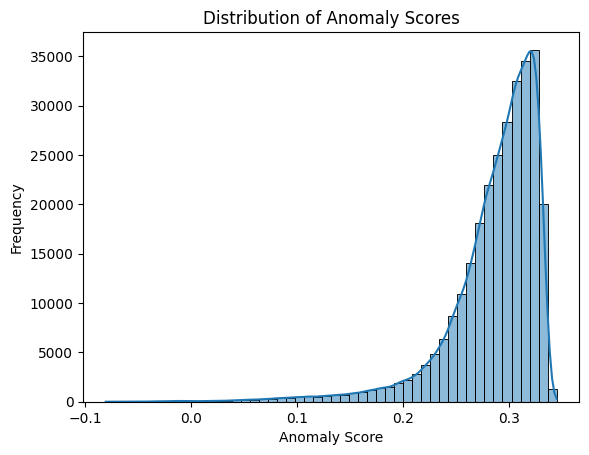

In [17]:
#anomaly score visualisation
sns.histplot(df['anomaly_score'], bins=50, kde= True)
plt.title("Distribution of Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

In [19]:
#analyze output
#-1 = anomaly, 1 = normal
df['anomaly'].value_counts()

anomaly
 1    284522
-1       285
Name: count, dtype: int64

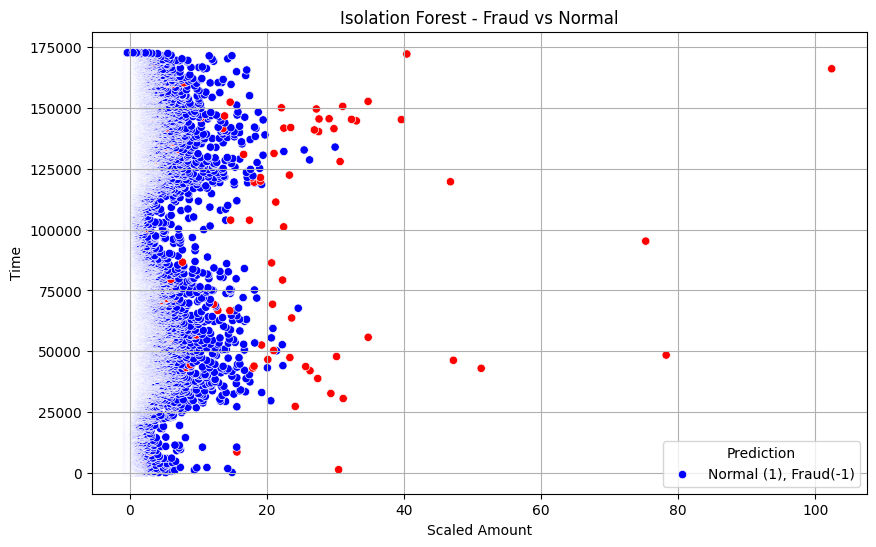

In [22]:
#visuzalize fraud cases
plt.figure(figsize=(10,6))
sns.scatterplot(data =df, x='scaled_amount', y='Time', hue='anomaly', palette={1:'blue',-1:'red' })
plt.title("Isolation Forest - Fraud vs Normal")
plt.xlabel("Scaled Amount")
plt.ylabel("Time")
plt.legend(title='Prediction', labels=['Normal (1), Fraud(-1)'])
plt.grid(True)
plt.show()